#### Name: Anlea Maria Jose, SE AIML, Roll No.: 02
#### Date: 28-01-2026
#### LR Using OLS

In [25]:
#Step 1: Imports
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize

In [26]:
#Step 2: Input data
x = np.array([1, 2, 3]).reshape(-1, 1)
y = np.array([2, 3, 5])

In [27]:
#Step 3: Create model and fit data
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
#Step 4: Get coefficients and print
w = model.coef_[0]
b = model.intercept_
print(f"The slope is {w}")
print(f"The intercept is {b}")

The slope is 1.4999999999999993
The intercept is 0.3333333333333348


In [29]:
#Step 6: Make predictions
y_pred = model.predict(x)
print("\nPredictions for training data")
for xi, yi, ypi in zip(x.flatten(), y, y_pred):
    print(f"x = {xi}, Actual y = {yi}, Predicted y = {ypi}")


Predictions for training data
x = 1, Actual y = 2, Predicted y = 1.8333333333333341
x = 2, Actual y = 3, Predicted y = 3.3333333333333335
x = 3, Actual y = 5, Predicted y = 4.833333333333333


In [30]:
#Step 7: Calculate Error
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"Mean Squared error is: {mse}")
print(f"R2_Score is: {r2}")

Mean Squared error is: 0.05555555555555553
R2_Score is: 0.9642857142857143


#### LR Using MLE

In [31]:
#Step 1: Imports
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
#Step 2: Input data
x = np.array([1, 2, 3])
y = np.array([2, 3, 5])

In [33]:
#Step 3: Negative Log Likelihood Function
def neg_log_likelihood(params):
    w, p = params
    sigma2 = 1
    y_pred = w*x + b
    nll = 0.5*np.sum(y-y_pred)**2/sigma2
    return nll

In [34]:
#Step 4: Assume initial values for w and p
initial_guess = [0, 0]

In [35]:
#Step 5: Minimise nll
result = minimize(neg_log_likelihood, initial_guess)
w_mle, b_mle = result.x
print(f"Slope is {w_mle}")
print(f"Intercept is {b_mle}")

Slope is 1.4999999895741052
Intercept is 0.0


In [36]:
#Step 6: Prediction
y_pred = w_mle*x + b_mle
print("\nPredictions for training data")
for xi, yi, ypi in zip(x.flatten(), y, y_pred):
    print(f"x = {xi}, Actual y = {yi}, Predicted y = {ypi}")


Predictions for training data
x = 1, Actual y = 2, Predicted y = 1.4999999895741052
x = 2, Actual y = 3, Predicted y = 2.9999999791482104
x = 3, Actual y = 5, Predicted y = 4.499999968722316


In [37]:
#Step 7: Calculate Error
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"Mean Squared error is: {mse}")
print(f"R2_Score is: {r2}")

Mean Squared error is: 0.16666668056786027
R2_Score is: 0.8928571339206612


#### LR Using GD

In [38]:
#Step 1: Imports
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [39]:
#Step 2: Input data
x = np.array([1, 2, 3])
y = np.array([2, 3, 5])

In [40]:
#Step 3: Input data
w, b = 0, 0
alpha = 0.001
n_iter = 10000
n = len(x)

In [41]:
for i in range(n_iter):
    y_pred = w*x.flatten() + b
    dw = (-2/n)*np.sum(x.flatten()*(y-y_pred))
    db = (-2/n)*np.sum(y-y_pred)
    w = w - alpha*dw
    b -= alpha*db
print(f"Slope is: {w}")
print(f"Bias is: {b}")

Slope is: 1.4891282998341364
Bias is: 0.35804726319993174


#### LR Using GD with single parameter

In [42]:
#Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt

In [43]:
#Step 2: Input data
x = np.array([1, 2, 3])
y = np.array([2, 3, 5])
n = len(x)

In [44]:
# Step 3: Calculate Loss Function
def loss(w1):
    w0 = np.mean(y) - w1*np.mean(x)
    y_pred = w1*x + w0
    return np.sum((y-y_pred)**2)
    

In [45]:
#Step 4: Calculate gradient of j wrt w1
def gradient(w1):
    w0 = np.mean(y) - w1*np.mean(x)
    y_pred = w1*x + w0
    return -2*np.sum(x*(y-y_pred))

In [46]:
#Step 5: Gradient Descent
lr = 0.1
w1 = 4
iter = 15
w1_values = []
loss_values = []

for i in range(iter):
    w1_values.append(w1)
    loss_values.append(loss(w1))
    grad = gradient(w1)
    w1 -= lr*grad

In [47]:
from numpy import linspace

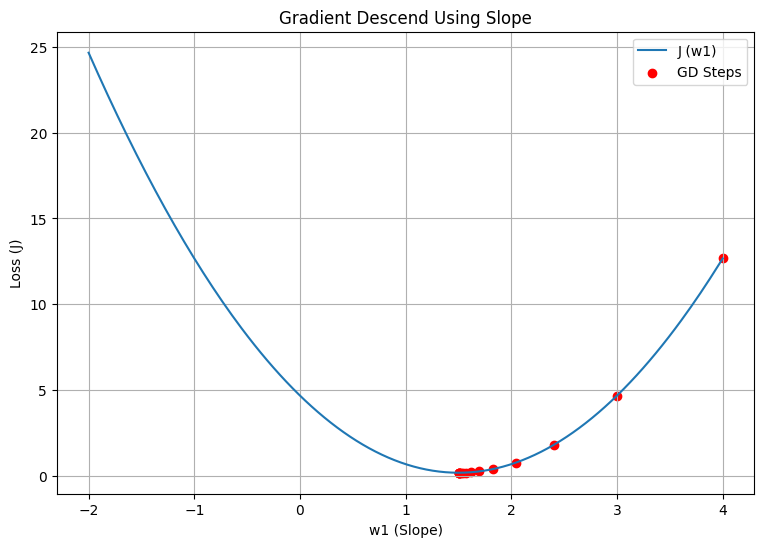

In [48]:
#Step 6: Plot loss function and GD

w_space = np.linspace(-2, 4, 200)
loss_space = [loss(w) for w in w_space]

plt.figure(figsize = (9,  6))
plt.plot(w_space, loss_space, label = "J (w1)")
plt.scatter(w1_values, loss_values, color="red", label="GD Steps")
plt.xlabel("w1 (Slope)")
plt.ylabel("Loss (J)")
plt.title("Gradient Descend Using Slope")
plt.legend()
plt.grid(True)
plt.show()